In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
notebook_path = Path.cwd()
base_path = notebook_path.parents[1]

raw_path = base_path / "data" / "raw" 
plot_path = base_path / "fig"

In [3]:
abund_mass = pd.read_csv(raw_path / "abundance_biomass.csv", sep=";")

# Parse month-year safely
abund_mass["year_month"] = pd.to_datetime(
    abund_mass["month"] + " " + abund_mass["year"].astype(str),
    format="%B %Y"
).dt.to_period("M")

In [10]:
# Aggregate first so each combination is unique
abund_summary = (
    abund_mass.groupby(["site", "replicate", "sample", "year_month"])
    .agg(
        abundance=("prawn_id", "count"),
        biomass=("dry_weight(g)", "sum")
    )
    .reset_index()
)

# Create complete range of months
all_months = pd.period_range(
    abund_summary["year_month"].min(),
    abund_summary["year_month"].max(),
    freq="M"
)

# Create all combinations
full_index = pd.MultiIndex.from_product(
    [
        abund_summary["site"].unique(),
        abund_summary["replicate"].unique(),
        abund_summary["sample"].unique(),
        all_months
    ],
    names=["site", "replicate", "sample", "year_month"]
)

# Reindex and keep missing combinations as NaN
abund_summary = (
    abund_summary
    .set_index(["site", "replicate", "sample", "year_month"])
    .reindex(full_index)
    .reset_index()
)

# Optional extra columns
abund_summary["year"] = abund_summary["year_month"].dt.year
abund_summary["month"] = abund_summary["year_month"].dt.strftime("%B")

In [11]:
# Total Abundance & Biomass per Site
total_ab_site = abund_summary.groupby(['site']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight(g)', 'sum')
).reset_index()

# Total Abundance & Biomass per Site and Replicate
total_ab_site_rep = abund_summary.groupby(['site', 'replicate']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight(g)', 'sum')
).reset_index()

# Total Abundance & Biomass per Site and Replicate
total_ab_series = abund_summary.groupby(['year_month', 'sample']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight(g)', 'sum')
).reset_index()

# Total Abundance & Biomass per Site and Replicate
total_ab_site_series = abund_summary.groupby(['site', 'year_month', 'sample']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight(g)', 'sum')
).reset_index()

# Total Abundance & Biomass per Site and Replicate
total_ab_site_rep_series = abund_summary.groupby(['site', 'replicate', 'year_month', 'sample']).agg(
    abundance=('prawn_id', 'count'),
    biomass=('dry_weight(g)', 'sum')
).reset_index()

KeyError: "Column(s) ['dry_weight(g)', 'prawn_id'] do not exist"

In [ ]:
# 2. ABC Curves per Site & Replicate
sites = total_ab_site_rep['site'].unique()
n_sites = len(sites)

fig, axes = plt.subplots(n_sites, 1, sharex=True)

for i, site in enumerate(sites):
    ax = axes[i] if n_sites > 1 else axes
    subset = total_ab_site_rep[total_ab_site_rep['site'] == site].sort_values(by='replicate', ascending=False)
    
    # Cumulative percentages
    subset['cum_abundance'] = subset['abundance'].cumsum() / subset['abundance'].sum() * 100
    subset['cum_biomass'] = subset['biomass'].cumsum() / subset['biomass'].sum() * 100
    
    ax.plot(range(1, len(subset)+1), subset['cum_abundance'], marker='o', label='Cumulative Abundance')
    ax.plot(range(1, len(subset)+1), subset['cum_biomass'], marker='s', label='Cumulative Biomass')
    ax.set_title(f'ABC Curve – Site {site}')
    ax.set_xticks(range(1, len(subset)+1))
    ax.grid(True)

axes[-1].set_xlabel('Replicate Sample Rank')
axes[1].set_ylabel('Cumulative Percentage (%)')
axes[1].legend()
plt.tight_layout()
plt.savefig(plot_path / "abc_curve.png", dpi=300)
plt.show()

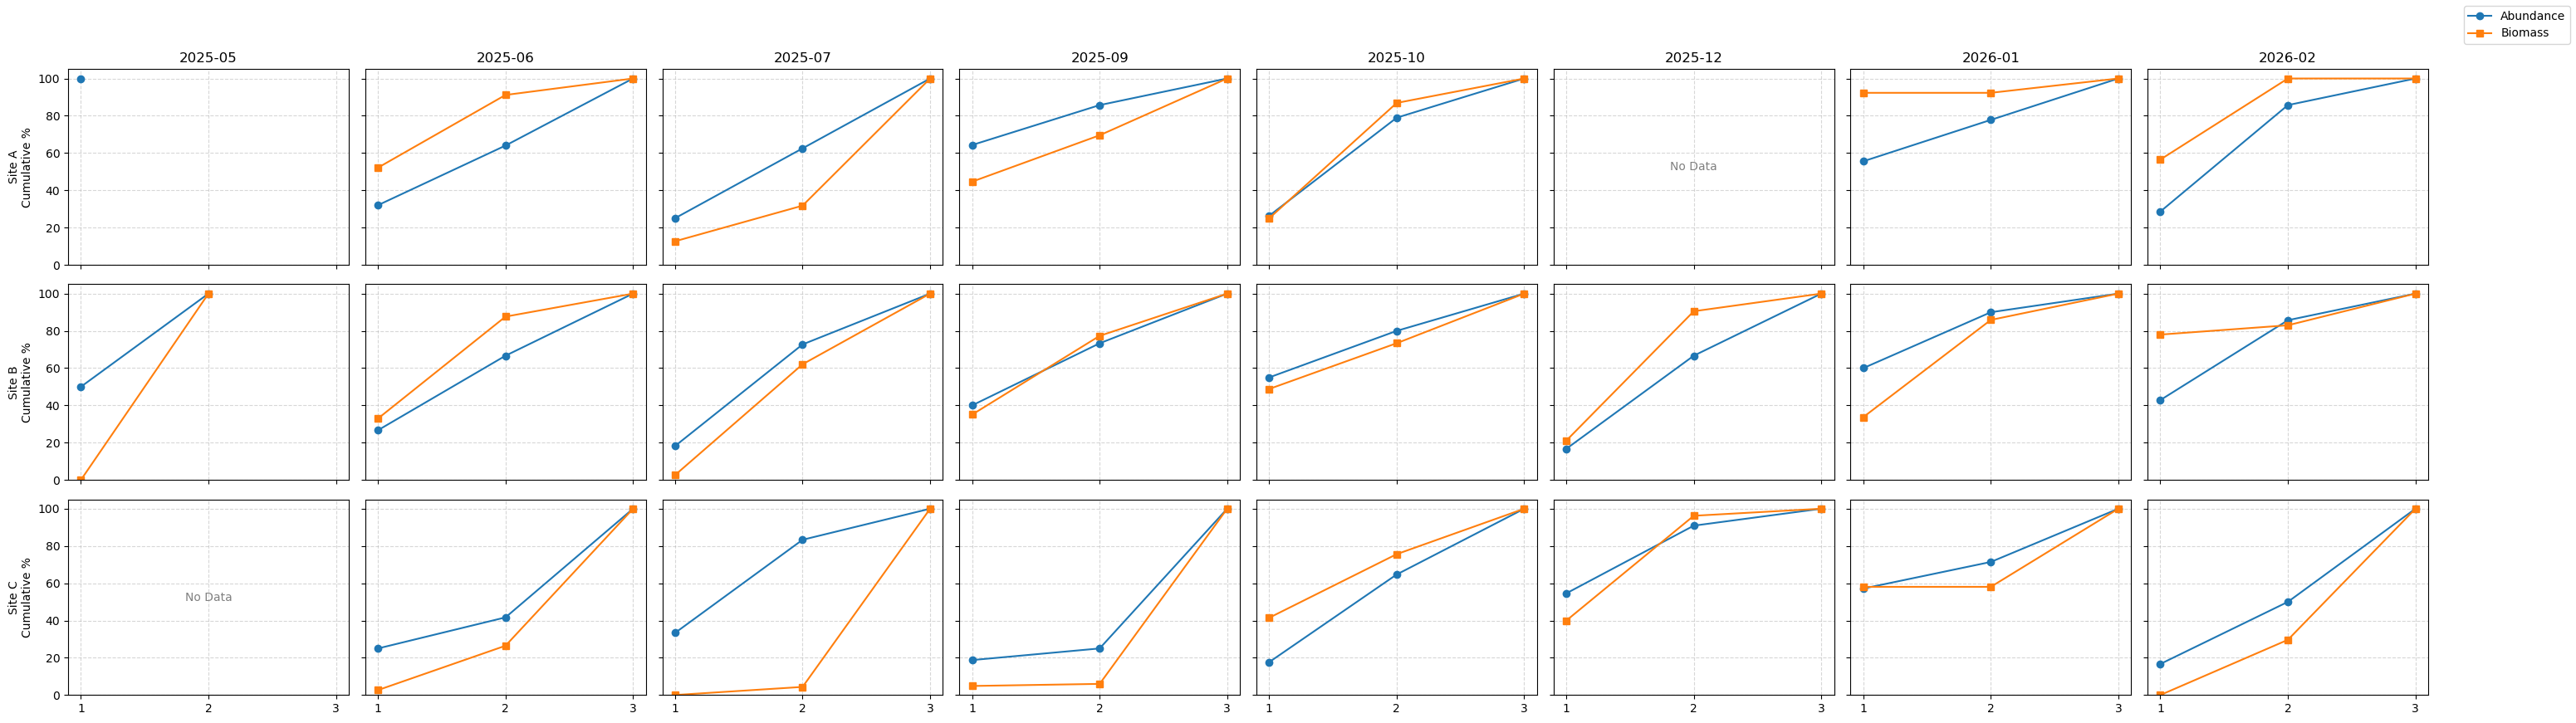

In [12]:
# Convert Period to string first
total_ab_site_rep_series["year_month"] = (
    total_ab_site_rep_series["year_month"].astype(str)
)

# Create ordered list of year-months present in the data
year_month_order = sorted(total_ab_site_rep_series["year_month"].unique())

sites = sorted(total_ab_site_rep_series['site'].unique())
n_sites = len(sites)
n_months = len(year_month_order)

fig, axes = plt.subplots(
    n_sites, n_months,
    figsize=(4 * n_months, 3 * n_sites),
    sharex=True, sharey=True
)

if n_sites == 1:
    axes = axes[np.newaxis, :]
if n_months == 1:
    axes = axes[:, np.newaxis]

for i, site in enumerate(sites):
    for j, ym in enumerate(year_month_order):
        ax = axes[i, j]

        subset = total_ab_site_rep_series[
            (total_ab_site_rep_series['site'] == site) &
            (total_ab_site_rep_series['year_month'] == ym)
        ].sort_values(by='replicate', ascending=False)

        if j == 0:
            ax.set_ylabel(f"Site {site}\nCumulative %")

        if subset.empty:
            ax.text(
                0.5, 0.5, "No Data",
                ha="center", va="center",
                transform=ax.transAxes, color="gray"
            )
            ax.set_ylim(0, 105)
        else:
            subset = subset.copy()

            subset['cum_abundance'] = (
                subset['abundance'].cumsum() / subset['abundance'].sum() * 100
            )
            subset['cum_biomass'] = (
                subset['biomass'].cumsum() / subset['biomass'].sum() * 100
            )

            x = range(1, len(subset) + 1)

            ax.plot(x, subset['cum_abundance'], marker='o', label='Abundance')
            ax.plot(x, subset['cum_biomass'], marker='s', label='Biomass')

            ax.set_xticks(x)
            ax.set_ylim(0, 105)

        if i == 0:
            ax.set_title(ym)

        ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout(rect=[0.03, 0.03, 0.95, 0.95])
plt.show()

In [13]:
# --- Unique sites ---
sites = sorted(total_ab_site_rep_series['site'].unique())
n_sites = len(sites)
n_months = len(month_order)

# --- Create subplot grid ---
fig, axes = plt.subplots(n_sites, n_months, figsize=(4*n_months, 3*n_sites), sharex=True, sharey=True)

# Ensure axes is 2D
if n_sites == 1:
    axes = axes[np.newaxis, :]
if n_months == 1:
    axes = axes[:, np.newaxis]

# --- Loop over site and month ---
for i, site in enumerate(sites):
    for j, month in enumerate(month_order):
        ax = axes[i, j]
        subset = total_ab_site_rep_series[
            (total_ab_site_rep_series['site'] == site) &
            (total_ab_site_rep_series['year_month'].str.lower() == month)
        ].sort_values(by='replicate', ascending=False)

        # Always set y-axis label on the first column
        if j == 0:
            ax.set_ylabel(f'Site {site}\nCumulative %', fontsize=10)

        if subset.empty:
            # Set placeholder x-ticks for vertical gridlines
            ax.set_xticks([1, 2, 3])
            ax.set_yticks([0, 25, 50, 75, 100])
            # Display "No Data" in center
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=9, color='gray', transform=ax.transAxes)
            # Keep gridlines
            ax.grid(True, which='both', linestyle='--', alpha=0.5)
        else:
            # --- Cumulative percentages ---
            subset['cum_abundance'] = subset['abundance'].cumsum() / subset['abundance'].sum() * 100
            subset['cum_biomass'] = subset['biomass'].cumsum() / subset['biomass'].sum() * 100

            # --- Plot ABC curve ---
            ax.plot(range(1, len(subset) + 1), subset['cum_abundance'], marker='o', label='Cumulative Abundance')
            ax.plot(range(1, len(subset) + 1), subset['cum_biomass'], marker='s', label='Cumulative Biomass')

            # --- Titles ---
            if i == 0:
                ax.set_title(f'Month {month.capitalize()}', fontsize=10)

            ax.grid(True, which='both', linestyle='--', alpha=0.5)
            ax.set_xticks(range(1, len(subset) + 1))
            ax.set_ylim(0, 105)

# --- Shared labels and legend ---
fig.text(0.5, 0.04, 'Replicate Sample Rank', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Cumulative Percentage (%)', va='center', rotation='vertical', fontsize=12)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=9)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.savefig(plot_path / "ABC_curve_time_series_finale.png", dpi=300)
plt.show()

NameError: name 'month_order' is not defined